# Guided Numeric Exploration — Global HIV/AIDS 1990–2024
_Exploratory walkthrough of prevalence, ART coverage, deaths, and regional burden_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [zohairbaloch/global-hivaids-dataset-19902024](https://www.kaggle.com/datasets/zohairbaloch/global-hivaids-dataset-19902024)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.
Indented lines signify code is part of a larger function or loop. Functions are used to keep the exploratory process simple and reusable.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Missingness and Coverage](#Missingness)** <br>
**4. [Univariate and Regional Burden](#Univariate)** <br>
**5. [Prevalence Trends Over Time](#Trends)** <br>
**6. [ART Coverage vs AIDS Deaths](#ART)** <br>
**7. [Income, GDP, and Life Expectancy](#Income)** <br>
**8. [Sub-Saharan Africa Deep Dive](#SSA)** <br>
**9. [High-Burden Country Trajectories](#Countries)** <br>
**10. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This notebook is a guided observational walkthrough of a country–year HIV/AIDS panel: **`clean_aids_dataset.csv`** with roughly **7,500 rows × 20 columns** spanning **1990–2024**, including World Bank region, income group, prevalence, ART coverage, AIDS deaths, and development covariates (GDP per capita, life expectancy).

My goal is to understand **how the epidemic's measured burden and treatment coverage evolved** — with Sub-Saharan Africa as the dominant high-prevalence region (section 8 zooms into that concentration) — while being explicit about **missingness**. Many HIV metrics are absent in early years; I will map coverage, then analyze complete-case subsets where needed. I will **not** silently impute key outcomes.

The dataset also ships `final_aids_dataset.csv` and regional aggregates; I prefer `clean_aids_dataset.csv` for the country panel (cleaner region field: `World_Bank_Region`). Interpretations are associational working notes, not causal evaluations of programs.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "clean_aids_dataset.csv"
KAGGLE_SLUG = "zohairbaloch/global-hivaids-dataset-19902024"

EXPECTED_COLS = [
    "Country", "ISO_Code", "World_Bank_Region", "Income_Group", "Year",
    "Population", "GDP_per_Capita", "Life_Expectancy", "Health_Expenditure",
    "Male_Population", "Female_Population", "People_Living_With_HIV",
    "HIV_Prevalence", "New_HIV_Infections", "AIDS_Deaths", "ART_Coverage",
    "Tuberculosis_HIV_Coinfection", "Source", "Urban_Population_Pct",
    "Poverty_Headcount_Ratio",
]

HIV_METRICS = [
    "HIV_Prevalence", "People_Living_With_HIV", "New_HIV_Infections",
    "AIDS_Deaths", "ART_Coverage", "Tuberculosis_HIV_Coinfection",
]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "aids" in p.name.lower() or "hiv" in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    assert p.exists(), f"expected {basename} under {root}; found {[x.name for x in root.iterdir()]}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)

# Region labels in the clean file can carry trailing whitespace — strip before any equality filters
df["World_Bank_Region"] = df["World_Bank_Region"].map(
    lambda x: x.strip() if isinstance(x, str) else x
)
assert not df["World_Bank_Region"].dropna().astype(str).str.contains(r"^\s|\s$", regex=True).any()

missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
assert len(df) >= 7000, f"unexpectedly small clean panel: {len(df)}"
assert df["Year"].between(1990, 2024).all(), "Year outside 1990–2024"

# Mention sibling files without switching analysis grain
root = csv_path.parent
siblings = sorted([p.name for p in root.glob("*.csv")])
print("Files in dataset package:", siblings)
for other in ["final_aids_dataset.csv", "aids_regional_aggregates.csv"]:
    p = root / other
    if p.exists():
        tmp = pd.read_csv(p, nrows=2)
        full_n = sum(1 for _ in open(p, "rb")) - 1
        print(f"  note: {other} exists (~{full_n} data rows, {tmp.shape[1]} cols) — analysis stays on clean country panel")

unique_count = []
for x in df.columns:
    unique_count.append([x, df[x].nunique(dropna=False), int(df[x].isnull().sum())])

print("Missing Values: {}".format(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Countries: {} | Years: {}–{}".format(df["Country"].nunique(), df["Year"].min(), df["Year"].max()))
print("HIV_Prevalence non-null share: {:.1%}".format(df["HIV_Prevalence"].notna().mean()))
print("ART_Coverage non-null share: {:.1%}".format(df["ART_Coverage"].notna().mean()))
print("AIDS_Deaths non-null share: {:.1%}".format(df["AIDS_Deaths"].notna().mean()))


Files in dataset package: ['aids_regional_aggregates.csv', 'clean_aids_dataset.csv', 'final_aids_dataset.csv']
  note: final_aids_dataset.csv exists (~7955 data rows, 26 cols) — analysis stays on clean country panel
  note: aids_regional_aggregates.csv exists (~455 data rows, 26 cols) — analysis stays on clean country panel
Missing Values: 33378
Dataframe Dimension: 7500 Rows, 20 Columns
Countries: 216 | Years: 1990–2024
HIV_Prevalence non-null share: 49.2%
ART_Coverage non-null share: 48.3%
AIDS_Deaths non-null share: 46.9%


**Code Explanation and Reasoning:** <br>
I assert the clean-panel schema and year bounds, strip trailing whitespace on `World_Bank_Region` (some labels ship with a trailing space — equality filters would silently miss Sub-Saharan Africa), then explicitly list sibling files so the choice of `clean_aids_dataset.csv` is documented — not accidental. I do **not** fill HIV metrics. Missingness is part of the measurement history (surveillance improved unevenly), so silent imputation would invent an epidemic narrative.


In [3]:
df.sample(3, random_state=7)


,Country,ISO_Code,World_Bank_Region,Income_Group,Year,Population,GDP_per_Capita,Life_Expectancy,Health_Expenditure,Male_Population,Female_Population,People_Living_With_HIV,HIV_Prevalence,New_HIV_Infections,AIDS_Deaths,ART_Coverage,Tuberculosis_HIV_Coinfection,Source,Urban_Population_Pct,Poverty_Headcount_Ratio
1229,Canada,CAN,North America,High income,1994,29000663.0,19997.623737,77.871707,NaN,14352168.0,14648495.0,NaN,NaN,NaN,NaN,NaN,NaN,WHO GHO / World Bank / Our World in Data / UNA...,77.317129,0.9
4291,Malta,MLT,"Middle East, North Africa, Afghanistan & Pakistan",High income,2000,390087.0,10348.485765,78.348780,6.626214,193158.0,196929.0,200.0,0.1,100.0,100.0,22.0,NaN,WHO GHO / World Bank / Our World in Data / UNA...,93.278339,NaN
7149,United States,USA,North America,High income,2024,340003797.0,86169.664158,78.890244,NaN,170826981.0,169176816.0,NaN,NaN,NaN,NaN,NaN,NaN,WHO GHO / World Bank / Our World in Data / UNA...,80.124780,1.1


In [4]:
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Missing"]).sort_values("Missing", ascending=False))
print("\nWorld_Bank_Region counts:\n", df["World_Bank_Region"].value_counts().to_string())
print("\nIncome_Group counts:\n", df["Income_Group"].value_counts().to_string())

Dataframe Dimension: 7500 Rows, 20 Columns


,Column,Unique,Missing
19,Poverty_Headcount_Ratio,488,5314
16,Tuberculosis_HIV_Coinfection,256,4563
13,New_HIV_Infections,257,3986
14,AIDS_Deaths,233,3985
15,ART_Coverage,99,3875
11,People_Living_With_HIV,360,3807
12,HIV_Prevalence,213,3807
8,Health_Expenditure,4466,3035
6,GDP_per_Capita,7055,446
18,Urban_Population_Pct,7036,80



World_Bank_Region counts:
 World_Bank_Region
Europe & Central Asia                                1960
Sub-Saharan Africa                                   1645
Latin America & Caribbean                            1400
East Asia & Pacific                                  1295
Middle East, North Africa, Afghanistan & Pakistan     805
South Asia                                            210
North America                                         105

Income_Group counts:
 Income_Group
High income            2905
Upper middle income    2030
Lower middle income    1645
Low income              840


**Interpretation** <br>
The panel is a rectangular country × year scaffold, but HIV outcome columns are roughly half-empty overall — and emptiness is concentrated in early years. Europe & Central Asia and Sub-Saharan Africa contribute the most country–years; burden will not be proportional to row counts. Income group and region will be my primary stratification axes.


# **3. Missingness and Coverage:** <a id="Missingness"></a>


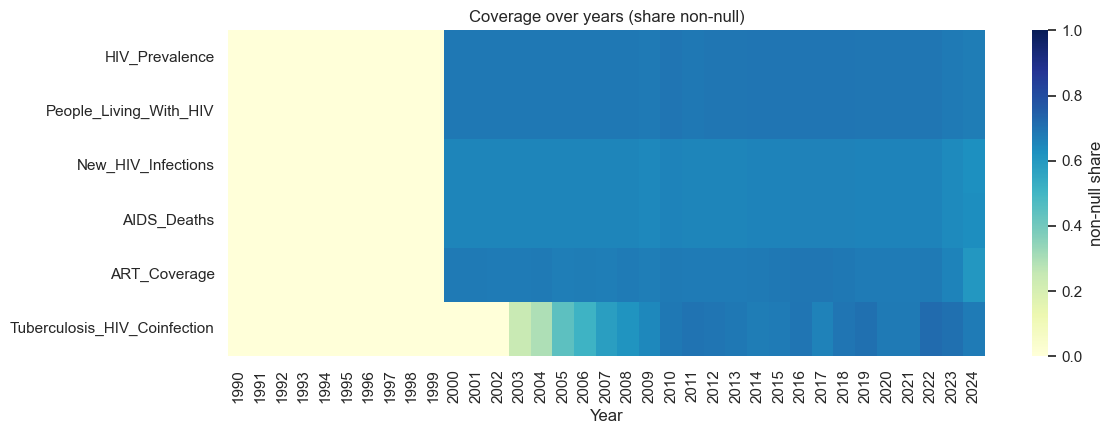

AGENT_SUMMARY coverage_1990:
 HIV_Prevalence                  0.0
People_Living_With_HIV          0.0
New_HIV_Infections              0.0
AIDS_Deaths                     0.0
ART_Coverage                    0.0
Tuberculosis_HIV_Coinfection    0.0
AGENT_SUMMARY coverage_2000:
 HIV_Prevalence                  0.687
People_Living_With_HIV          0.687
New_HIV_Infections              0.654
AIDS_Deaths                     0.654
ART_Coverage                    0.682
Tuberculosis_HIV_Coinfection    0.000
AGENT_SUMMARY coverage_2020:
 HIV_Prevalence                  0.690
People_Living_With_HIV          0.690
New_HIV_Infections              0.657
AIDS_Deaths                     0.657
ART_Coverage                    0.676
Tuberculosis_HIV_Coinfection    0.681


In [5]:
# Missingness heatmap over years for key HIV metrics
coverage = (
    df.groupby("Year")[HIV_METRICS]
    .apply(lambda g: g.notna().mean())
)
coverage.index = coverage.index.astype(int)

f, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(coverage.T, cmap="YlGnBu", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "non-null share"})
ax.set_title("Coverage over years (share non-null)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY coverage_1990:\n", coverage.loc[1990].round(3).to_string() if 1990 in coverage.index else "n/a")
print("AGENT_SUMMARY coverage_2000:\n", coverage.loc[2000].round(3).to_string() if 2000 in coverage.index else "n/a")
print("AGENT_SUMMARY coverage_2020:\n", coverage.loc[2020].round(3).to_string() if 2020 in coverage.index else "n/a")


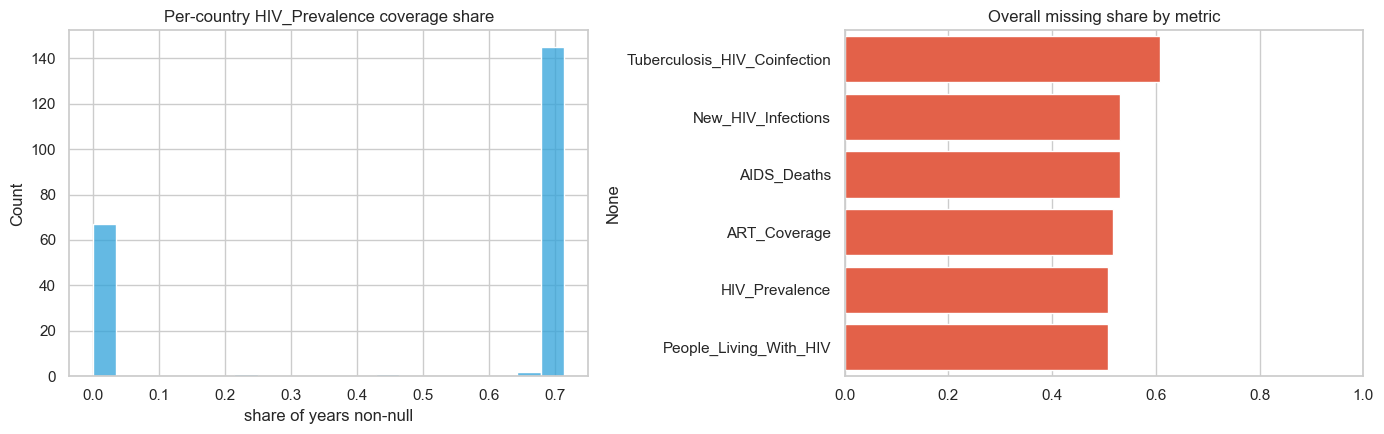

AGENT_SUMMARY metric_missing:
 Tuberculosis_HIV_Coinfection    0.608
New_HIV_Infections              0.531
AIDS_Deaths                     0.531
ART_Coverage                    0.517
HIV_Prevalence                  0.508
People_Living_With_HIV          0.508
AGENT_SUMMARY countries_with_zero_prevalence_data=66
AGENT_SUMMARY countries_with_full_prevalence_data=0


In [6]:
# Country-level missingness for HIV_Prevalence
country_cov = df.groupby("Country")["HIV_Prevalence"].apply(lambda s: s.notna().mean()).sort_values()
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(country_cov, bins=20, ax=ax[0], color="#30a2da")
ax[0].set_title("Per-country HIV_Prevalence coverage share")
ax[0].set_xlabel("share of years non-null")

# Metric missingness bar
miss = df[HIV_METRICS].isna().mean().sort_values(ascending=False)
sns.barplot(x=miss.values, y=miss.index, ax=ax[1], color="#fc4f30")
ax[1].set_title("Overall missing share by metric")
ax[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY metric_missing:\n", miss.round(3).to_string())
print("AGENT_SUMMARY countries_with_zero_prevalence_data={}".format((country_cov == 0).sum()))
print("AGENT_SUMMARY countries_with_full_prevalence_data={}".format((country_cov == 1).sum()))


**How to Interpret:** <br>
Darker cells in the year heatmap mean denser reporting. Early 1990s often show near-zero coverage for prevalence/ART/deaths; denser surveillance appears later. Country coverage is uneven — some states have almost no prevalence years. Every trend plot below should be read as *among observed cells*, not as a fully balanced panel.


# **4. Univariate and Regional Burden:** <a id="Univariate"></a>


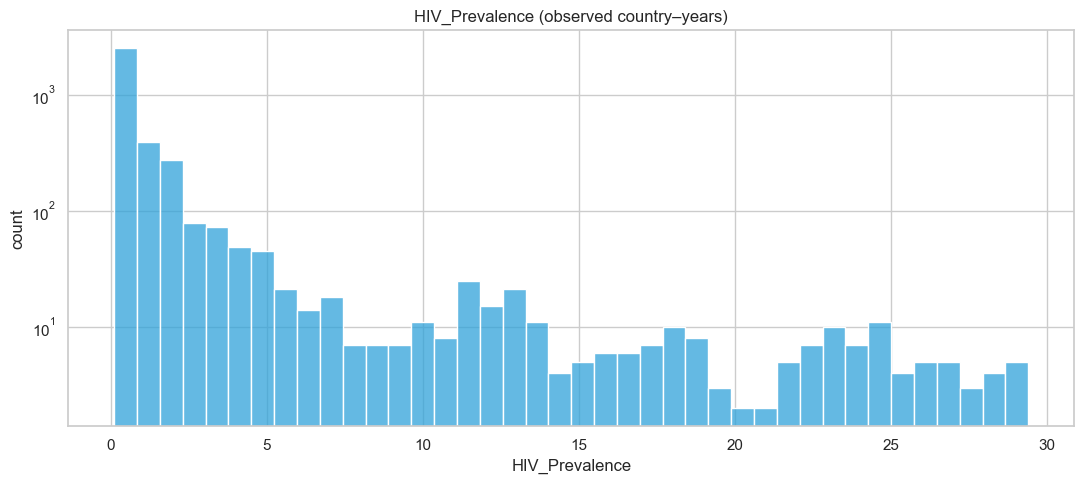

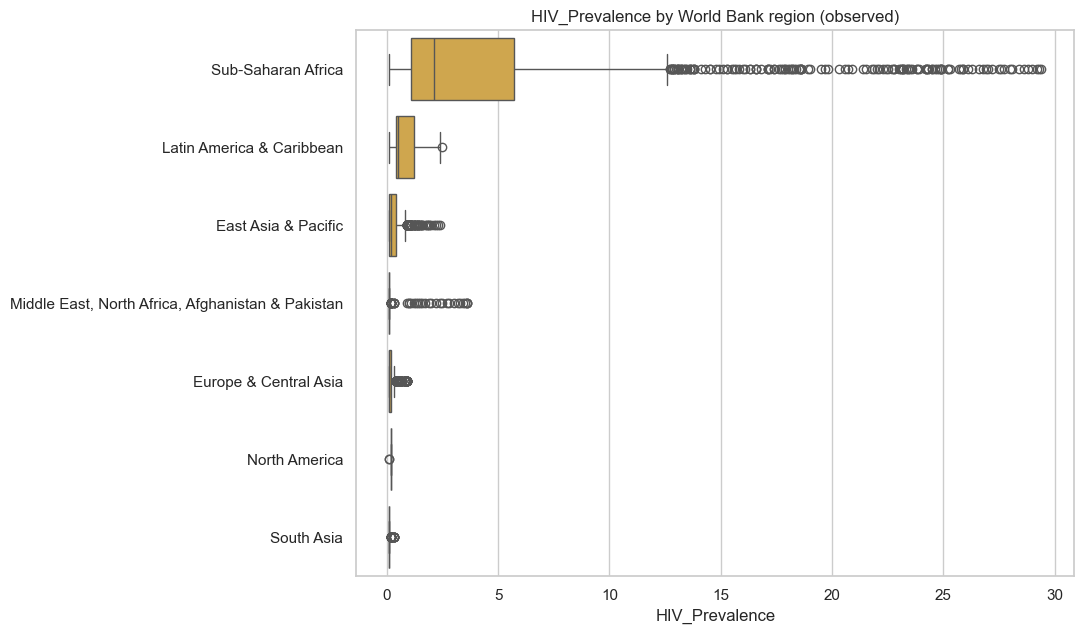

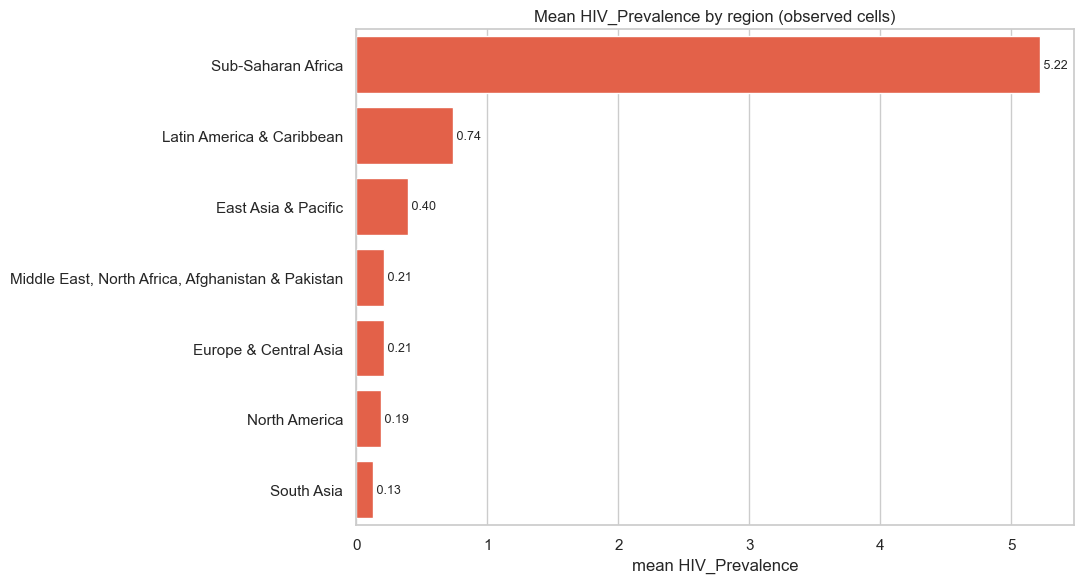

AGENT_SUMMARY region_mean_prevalence:
 World_Bank_Region
Sub-Saharan Africa                                   5.219
Latin America & Caribbean                            0.738
East Asia & Pacific                                  0.396
Middle East, North Africa, Afghanistan & Pakistan    0.213
Europe & Central Asia                                0.212
North America                                        0.191
South Asia                                           0.126
AGENT_SUMMARY prevalence_observed_n=3693 mean=1.783 p90=3.900


In [7]:
# Complete-case snapshots for distribution shape (no imputation)
# Each view gets its own figure so long region labels have room.
prev = df.dropna(subset=["HIV_Prevalence"]).copy()
assert len(prev) > 1000

region_mean = (
    prev.groupby("World_Bank_Region")["HIV_Prevalence"]
    .mean()
    .sort_values(ascending=False)
)
region_order = region_mean.index.tolist()

# 1) Prevalence histogram
f, ax = plt.subplots(figsize=(11, 5))
sns.histplot(prev["HIV_Prevalence"], bins=40, ax=ax, color="#30a2da")
ax.set_title("HIV_Prevalence (observed country–years)")
ax.set_xlabel("HIV_Prevalence")
ax.set_ylabel("count")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

# 2) Boxplot by region — horizontal so long labels stay readable
f, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(
    data=prev,
    y="World_Bank_Region",
    x="HIV_Prevalence",
    order=region_order,
    color="#e5ae38",
    ax=ax,
)
ax.set_title("HIV_Prevalence by World Bank region (observed)")
ax.set_xlabel("HIV_Prevalence")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 3) Mean prevalence by region
f, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    x=region_mean.values,
    y=region_mean.index.astype(str),
    color="#fc4f30",
    ax=ax,
)
ax.set_title("Mean HIV_Prevalence by region (observed cells)")
ax.set_xlabel("mean HIV_Prevalence")
ax.set_ylabel("")
for i, v in enumerate(region_mean.values):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY region_mean_prevalence:\n", region_mean.round(3).to_string())
print("AGENT_SUMMARY prevalence_observed_n={} mean={:.3f} p90={:.3f}".format(
    len(prev), prev["HIV_Prevalence"].mean(), prev["HIV_Prevalence"].quantile(0.9)
))


**Interpretation:** <br>
Prevalence is heavily right-skewed: most observed country–years sit low, while a high-burden tail — dominated by Sub-Saharan Africa — pulls means. I split the histogram, region boxplot, and mean bar into **dedicated figures** so long `World_Bank_Region` labels stay readable. The horizontal boxplot makes regional dominance visual; row counts alone would not.


# **5. Prevalence Trends Over Time:** <a id="Trends"></a>


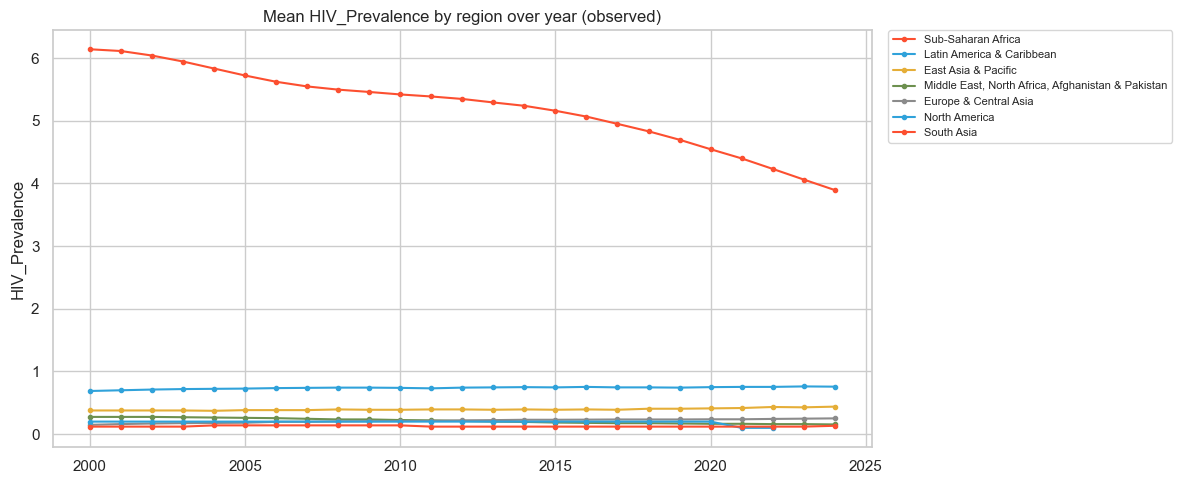

AGENT_SUMMARY global_prevalence_tail:
        mean  median  count
Year                      
2015  1.763    0.35    148
2016  1.727    0.30    149
2017  1.691    0.30    149
2018  1.659    0.30    149
2019  1.619    0.30    149
2020  1.577    0.40    149
2021  1.536    0.40    149
2022  1.490    0.40    149
2023  1.460    0.40    147
2024  1.428    0.40    145
AGENT_SUMMARY ssa_vs_other_latest:
World_Bank_Region
other    0.387
SSA      3.895


In [8]:
# Regional mean prevalence over years (observed cells only)
reg_year = (
    df.dropna(subset=["HIV_Prevalence"])
    .groupby(["Year", "World_Bank_Region"], as_index=False)["HIV_Prevalence"]
    .mean()
)

f, ax = plt.subplots(figsize=(12, 5))
for region, color in zip(
    reg_year.groupby("World_Bank_Region")["HIV_Prevalence"].mean().sort_values(ascending=False).index,
    ["#fc4f30", "#30a2da", "#e5ae38", "#6d904f", "#8b8b8b", "#30a2da", "#fc4f30"],
):
    sub = reg_year[reg_year["World_Bank_Region"] == region]
    ax.plot(sub["Year"], sub["HIV_Prevalence"], marker=".", label=region, color=color)
ax.set_title("Mean HIV_Prevalence by region over year (observed)")
ax.set_ylabel("HIV_Prevalence")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

# Global observed mean vs median
g = df.dropna(subset=["HIV_Prevalence"]).groupby("Year")["HIV_Prevalence"].agg(["mean", "median", "count"])
print("AGENT_SUMMARY global_prevalence_tail:\n", g.tail(10).round(3).to_string())
print("AGENT_SUMMARY ssa_vs_other_latest:")
latest = df["Year"].max()
snap = df[(df["Year"] == latest) & df["HIV_Prevalence"].notna()]
if len(snap):
    print(snap.groupby(snap["World_Bank_Region"].eq("Sub-Saharan Africa"))["HIV_Prevalence"].mean().rename({True: "SSA", False: "other"}).round(3).to_string())
else:
    # fall back to last year with prevalence data
    y = df.loc[df["HIV_Prevalence"].notna(), "Year"].max()
    snap = df[(df["Year"] == y) & df["HIV_Prevalence"].notna()]
    print("using year", y)
    print(snap.groupby(snap["World_Bank_Region"].eq("Sub-Saharan Africa"))["HIV_Prevalence"].mean().rename({True: "SSA", False: "other"}).round(3).to_string())


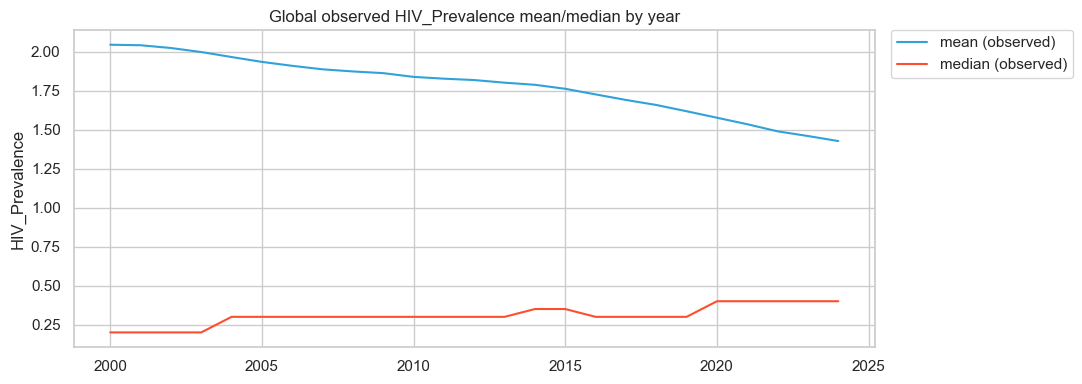

AGENT_SUMMARY n_countries_with_prevalence_by_year_minmax=145–149


In [9]:
f, ax = plt.subplots(figsize=(11, 4))
ax.plot(g.index, g["mean"], color="#30a2da", label="mean (observed)")
ax.plot(g.index, g["median"], color="#fc4f30", label="median (observed)")
ax.set_title("Global observed HIV_Prevalence mean/median by year")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.set_ylabel("HIV_Prevalence")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY n_countries_with_prevalence_by_year_minmax={}–{}".format(int(g["count"].min()), int(g["count"].max())))


**How to Interpret:** <br>
Regional lines use *means of observed cells* each year — when coverage jumps, composition can jump too. Sub-Saharan Africa's separation from other regions is the headline. Global mean vs median shows skew: a high-burden tail keeps the mean above the median.


# **6. ART Coverage vs AIDS Deaths:** <a id="ART"></a>


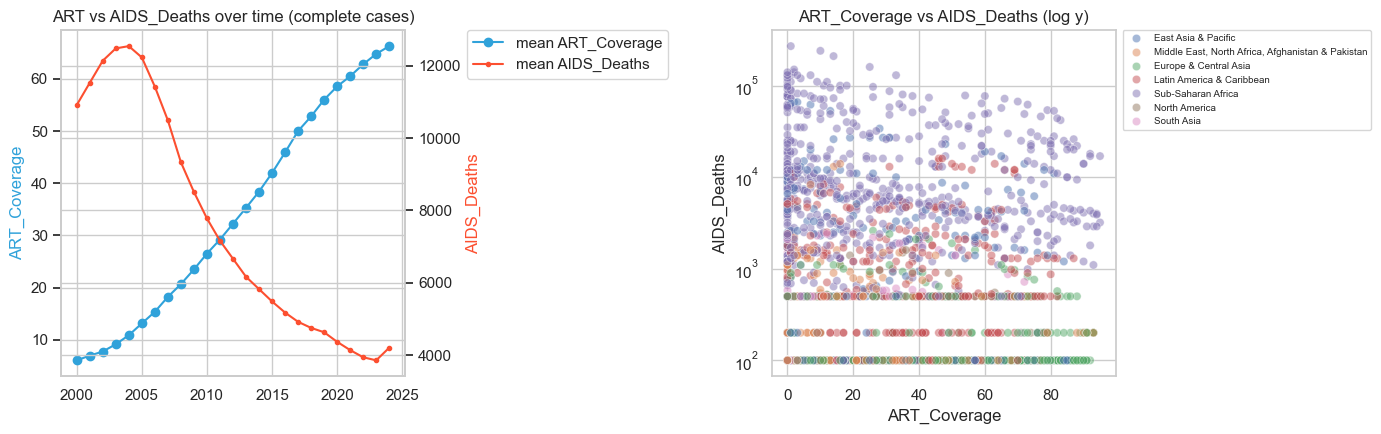

AGENT_SUMMARY art_deaths_complete_n=3449
AGENT_SUMMARY spearman ART~AIDS_Deaths=-0.152 p=2.8e-19
AGENT_SUMMARY yearly_art_deaths_tail:
  Year  mean_art  mean_deaths   n
 2017     50.00      4918.16 141
 2018     52.80      4749.71 140
 2019     56.01      4629.50 139
 2020     58.55      4364.68 139
 2021     60.50      4135.90 139
 2022     62.80      3937.84 139
 2023     64.78      3852.84 134
 2024     66.27      4201.77 124


In [10]:
# Where both ART and deaths are available — no imputation
both = df.dropna(subset=["ART_Coverage", "AIDS_Deaths"]).copy()
assert len(both) > 500, "too few complete ART+deaths rows"
both["deaths_per_100k"] = np.where(
    both["Population"] > 0,
    both["AIDS_Deaths"] / both["Population"] * 100_000,
    np.nan,
)

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
yearly_both = both.groupby("Year").agg(
    mean_art=("ART_Coverage", "mean"),
    mean_deaths=("AIDS_Deaths", "mean"),
    n=("ART_Coverage", "size"),
).reset_index()
ax[0].plot(yearly_both["Year"], yearly_both["mean_art"], color="#30a2da", marker="o", label="mean ART_Coverage")
ax[0].set_ylabel("ART_Coverage", color="#30a2da")
ax2 = ax[0].twinx()
ax2.plot(yearly_both["Year"], yearly_both["mean_deaths"], color="#fc4f30", marker=".", label="mean AIDS_Deaths")
ax2.set_ylabel("AIDS_Deaths", color="#fc4f30")
ax[0].set_title("ART vs AIDS_Deaths over time (complete cases)")
# Manual legend to the right
lines = ax[0].get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax[0].legend(lines, labels, loc="upper left", bbox_to_anchor=(1.18, 1), borderaxespad=0)

sample = both.sample(min(2000, len(both)), random_state=0)
sns.scatterplot(data=sample, x="ART_Coverage", y="AIDS_Deaths", hue="World_Bank_Region", ax=ax[1], alpha=0.5, legend=True)
ax[1].set_yscale("log")
ax[1].set_title("ART_Coverage vs AIDS_Deaths (log y)")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=7)
plt.tight_layout()
plt.show()

rho = stats.spearmanr(both["ART_Coverage"], both["AIDS_Deaths"])
print("AGENT_SUMMARY art_deaths_complete_n={}".format(len(both)))
print("AGENT_SUMMARY spearman ART~AIDS_Deaths={:.3f} p={:.2g}".format(rho.correlation, rho.pvalue))
print("AGENT_SUMMARY yearly_art_deaths_tail:\n", yearly_both.tail(8).round(2).to_string(index=False))


**Interpretation:** <br>
Where both series exist, ART coverage generally rises while average AIDS deaths fall — the classic treatment-era transition *in observed cells*. The scatter is messy because countries differ in epidemic size; log deaths helps, but population scaling and lag structures still matter. Cross-sectional Spearman can be weak or even counterintuitive if high-burden countries scale up ART while still recording many deaths.


# **7. Income, GDP, and Life Expectancy:** <a id="Income"></a>


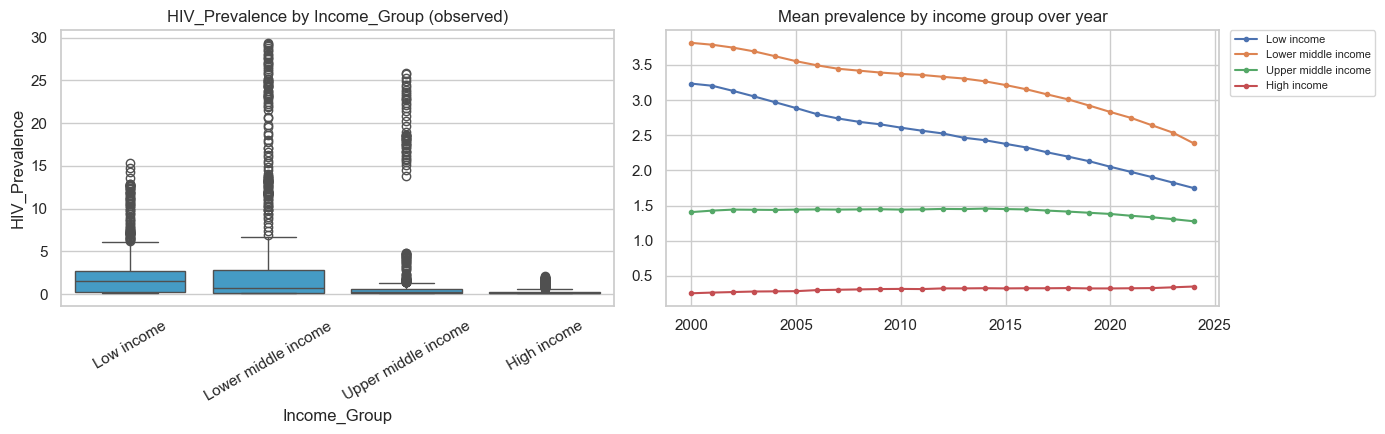

AGENT_SUMMARY income_prevalence:
                       mean  median  count
Income_Group                             
High income          0.309     0.1   1017
Low income           2.510     1.5    575
Lower middle income  3.244     0.7   1026
Upper middle income  1.417     0.3   1050


In [11]:
prev_inc = df.dropna(subset=["HIV_Prevalence", "Income_Group"]).copy()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
order = prev_inc.groupby("Income_Group")["HIV_Prevalence"].median().sort_values(ascending=False).index
sns.boxplot(data=prev_inc, x="Income_Group", y="HIV_Prevalence", order=order, ax=ax[0], color="#30a2da")
ax[0].set_title("HIV_Prevalence by Income_Group (observed)")
ax[0].tick_params(axis="x", rotation=30)

inc_year = prev_inc.groupby(["Year", "Income_Group"], as_index=False)["HIV_Prevalence"].mean()
for grp in order:
    sub = inc_year[inc_year["Income_Group"] == grp]
    ax[1].plot(sub["Year"], sub["HIV_Prevalence"], marker=".", label=grp)
ax[1].set_title("Mean prevalence by income group over year")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY income_prevalence:\n",
      prev_inc.groupby("Income_Group")["HIV_Prevalence"].agg(["mean", "median", "count"]).round(3).to_string())


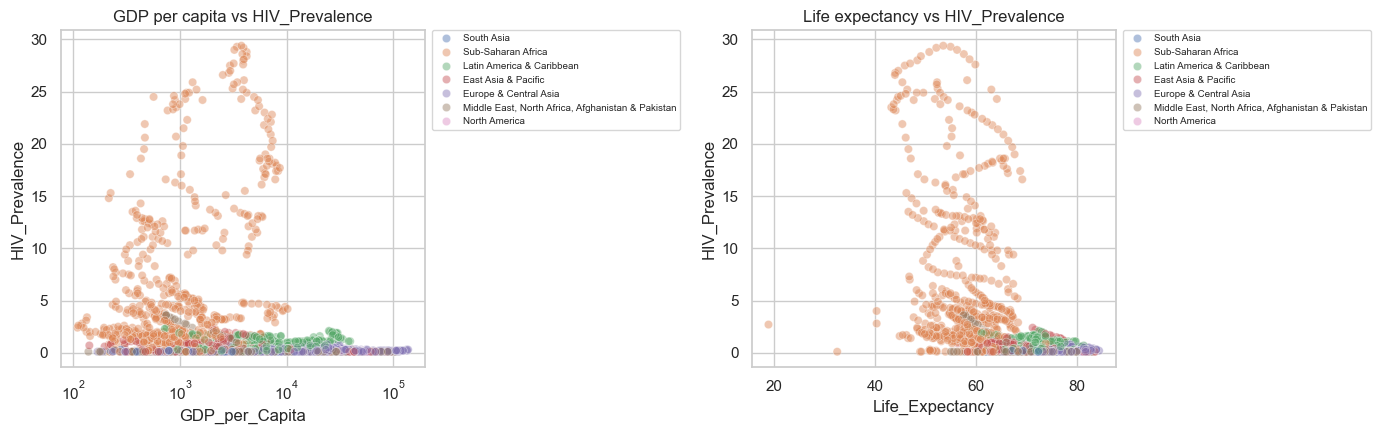

AGENT_SUMMARY spearman GDP~prevalence=-0.378 LE~prevalence=-0.580 n=3617


In [12]:
# GDP / life expectancy associations with prevalence (associational, complete cases)
assoc = df.dropna(subset=["HIV_Prevalence", "GDP_per_Capita", "Life_Expectancy"]).copy()
assert len(assoc) > 500

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sample = assoc.sample(min(2500, len(assoc)), random_state=1)
sns.scatterplot(data=sample, x="GDP_per_Capita", y="HIV_Prevalence", hue="World_Bank_Region", alpha=0.45, ax=ax[0])
ax[0].set_xscale("log")
ax[0].set_title("GDP per capita vs HIV_Prevalence")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=7)

sns.scatterplot(data=sample, x="Life_Expectancy", y="HIV_Prevalence", hue="World_Bank_Region", alpha=0.45, ax=ax[1])
ax[1].set_title("Life expectancy vs HIV_Prevalence")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=7)
plt.tight_layout()
plt.show()

r_gdp = stats.spearmanr(assoc["GDP_per_Capita"], assoc["HIV_Prevalence"])
r_le = stats.spearmanr(assoc["Life_Expectancy"], assoc["HIV_Prevalence"])
print("AGENT_SUMMARY spearman GDP~prevalence={:.3f} LE~prevalence={:.3f} n={}".format(
    r_gdp.correlation, r_le.correlation, len(assoc)
))


**How to Interpret:** <br>
Income-group boxes and lines are descriptive epidemiology, not a claim that income "causes" prevalence. GDP and life expectancy associations are similarly associational — reverse causality and regional clustering (especially Southern Africa) dominate any naive reading. I use them to situate burden in development space, not to rank policy.


# **8. Sub-Saharan Africa Deep Dive:** <a id="SSA"></a>
### 8.1 How dominant is the regional concentration?
Regional means already flag Sub-Saharan Africa (SSA). Here I quantify that concentration with complete-case views: share of observed prevalence *mass*, population-weighted prevalence, and people living with HIV — then open the within-region map so "SSA dominates" is not treated as homogeneous.


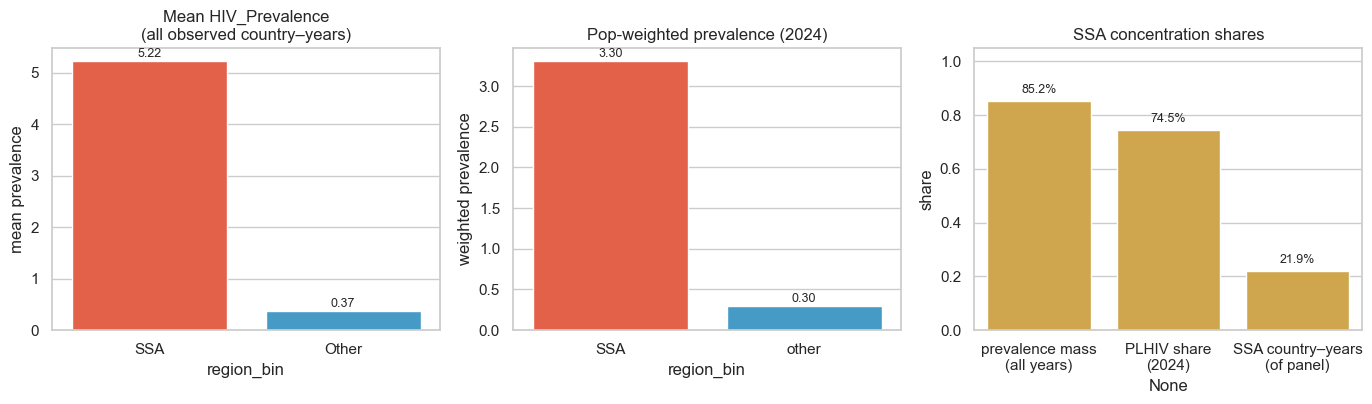

AGENT_SUMMARY ssa_dominance:
  latest_dense_year=2024
  ssa_countries=47 ssa_rows=1645
  prevalence_mass_share=0.852
  plhiv_share_2024=0.745
  pop_weighted_prev:
region_bin
SSA      3.302
other    0.299
  unweighted_mean_prev:
region_bin
SSA      5.219
Other    0.372


In [13]:
# SSA mask after strip — fail loud if the region label drifts
SSA_LABEL = "Sub-Saharan Africa"
assert SSA_LABEL in set(df["World_Bank_Region"].dropna().unique()), (
    f"expected {SSA_LABEL!r} in regions: {sorted(df['World_Bank_Region'].dropna().unique())}"
)
ssa = df["World_Bank_Region"].eq(SSA_LABEL)
df_ssa = df.loc[ssa].copy()
assert df_ssa["Country"].nunique() >= 40

obs_prev = df["HIV_Prevalence"].notna()
prev_mass_ssa = df.loc[obs_prev & ssa, "HIV_Prevalence"].sum() / df.loc[obs_prev, "HIV_Prevalence"].sum()

# Latest year with dense prevalence coverage
years_cov = (
    df.groupby("Year")["HIV_Prevalence"]
    .apply(lambda s: s.notna().mean())
    .loc[lambda s: s >= 0.35]
)
assert len(years_cov) > 0
y = int(years_cov.index.max())
snap = df[(df["Year"] == y) & df["HIV_Prevalence"].notna()].copy()
assert snap["Population"].notna().mean() > 0.8

snap["prev_pop"] = snap["HIV_Prevalence"] * snap["Population"]
snap["region_bin"] = np.where(snap["World_Bank_Region"].eq(SSA_LABEL).to_numpy(), "SSA", "other")
pop_w = (
    snap.groupby("region_bin", sort=False)
    .apply(lambda g: g["prev_pop"].sum() / g["Population"].sum(), include_groups=False)
    .reindex(["SSA", "other"])
)

plhiv = snap.dropna(subset=["People_Living_With_HIV"])
plhiv_share = (
    plhiv.loc[plhiv["World_Bank_Region"].eq(SSA_LABEL), "People_Living_With_HIV"].sum()
    / plhiv["People_Living_With_HIV"].sum()
)

f, ax = plt.subplots(1, 3, figsize=(14, 4.2))
# 1) unweighted mean prevalence SSA vs other (observed cells, all years)
tmp = df.loc[obs_prev].copy()
tmp["region_bin"] = np.where(tmp["World_Bank_Region"].eq(SSA_LABEL).to_numpy(), "SSA", "Other")
cmp = tmp.groupby("region_bin")["HIV_Prevalence"].mean().reindex(["SSA", "Other"])
sns.barplot(x=cmp.index, y=cmp.values, ax=ax[0], palette=["#fc4f30", "#30a2da"])
ax[0].set_title("Mean HIV_Prevalence\n(all observed country–years)")
ax[0].set_ylabel("mean prevalence")
for i, v in enumerate(cmp.values):
    ax[0].text(i, v + 0.08, f"{v:.2f}", ha="center", fontsize=9)

# 2) pop-weighted prevalence in latest dense year
sns.barplot(x=pop_w.index.astype(str), y=pop_w.values, ax=ax[1], palette=["#fc4f30", "#30a2da"])
ax[1].set_title(f"Pop-weighted prevalence ({y})")
ax[1].set_ylabel("weighted prevalence")
for i, v in enumerate(pop_w.values):
    ax[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

# 3) share bars
shares = pd.Series({
    "prevalence mass\n(all years)": prev_mass_ssa,
    f"PLHIV share\n({y})": plhiv_share,
    "SSA country–years\n(of panel)": float(ssa.mean()),
})
sns.barplot(x=shares.index, y=shares.values, ax=ax[2], color="#e5ae38")
ax[2].set_ylim(0, 1.05)
ax[2].set_title("SSA concentration shares")
ax[2].set_ylabel("share")
for i, v in enumerate(shares.values):
    ax[2].text(i, v + 0.03, f"{v:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY ssa_dominance:")
print(f"  latest_dense_year={y}")
print(f"  ssa_countries={df_ssa['Country'].nunique()} ssa_rows={len(df_ssa)}")
print(f"  prevalence_mass_share={prev_mass_ssa:.3f}")
print(f"  plhiv_share_{y}={plhiv_share:.3f}")
print(f"  pop_weighted_prev:\n{pop_w.round(3).to_string()}")
print(f"  unweighted_mean_prev:\n{cmp.round(3).to_string()}")


**How to Interpret:** <br>
*Prevalence mass* sums observed `HIV_Prevalence` cells — it is not a person count, but it shows where high rates sit in the panel. Population-weighted prevalence and PLHIV share answer the "where people are" question. If SSA's share of prevalence mass and PLHIV far exceeds its share of country–years, concentration is real, not a row-count artifact.

**Interpretation:** <br>
Expect SSA to clear the other regions on all three lenses. The interesting follow-up is *within* SSA: southern African states vs a long lower-prevalence tail across West/Central/East Africa.


### 8.2 Within-SSA prevalence landscape
Forty-plus countries share one World Bank region label. I rank the latest dense year, show the within-SSA distribution, and mark a Southern Africa cluster that historically carries the extreme right tail.


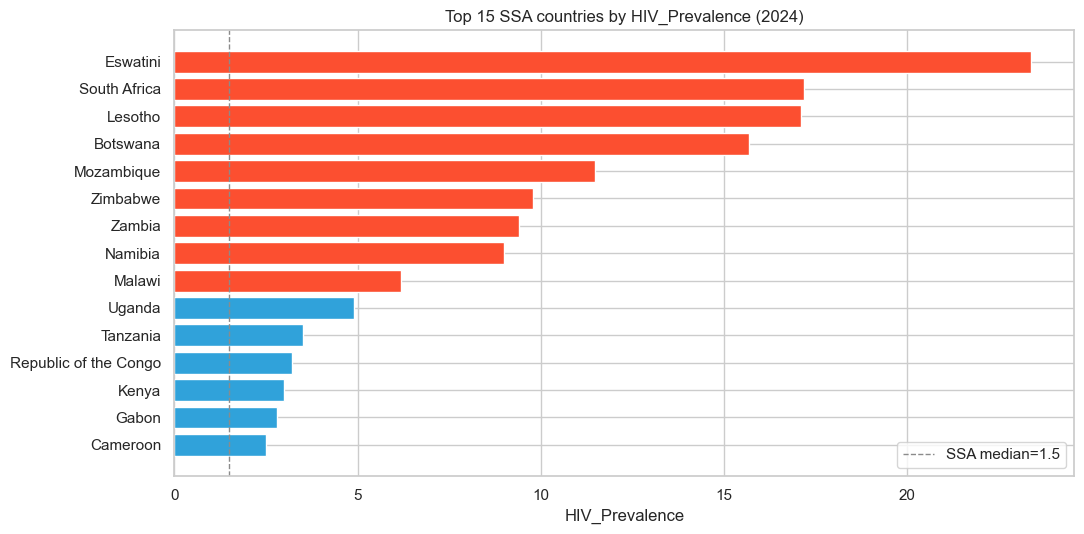

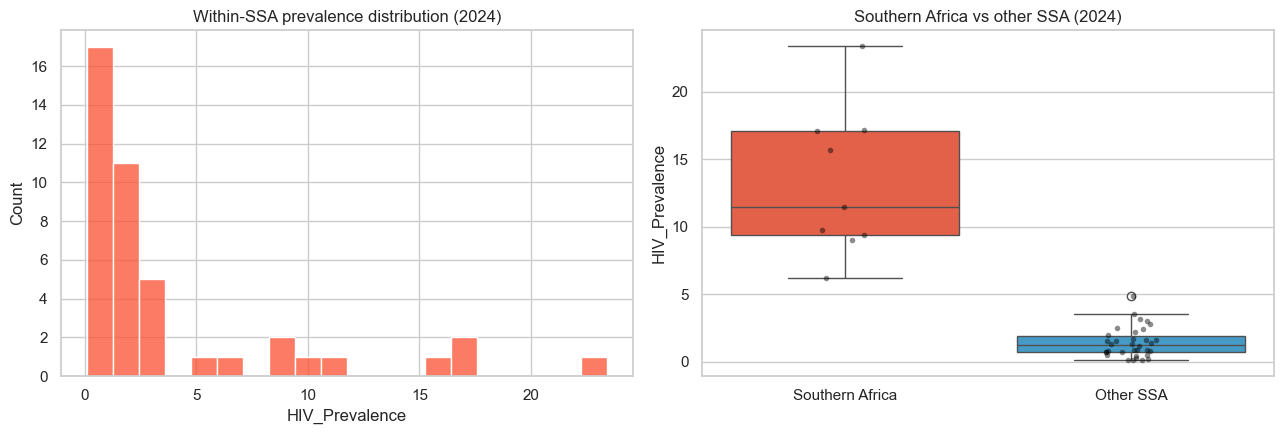

AGENT_SUMMARY ssa_within_landscape_year=2024
                 count    mean  median   max
cluster                                     
Southern Africa      9  13.256   11.50  23.4
Other SSA           34   1.418    1.25   4.9
AGENT_SUMMARY ssa_top10:
      Country  HIV_Prevalence  ART_Coverage  AIDS_Deaths         cluster
    Eswatini            23.4          94.0       2900.0 Southern Africa
South Africa            17.2          81.0      53000.0 Southern Africa
     Lesotho            17.1          94.0       4000.0 Southern Africa
    Botswana            15.7          95.0       3800.0 Southern Africa
  Mozambique            11.5          82.0      44000.0 Southern Africa
    Zimbabwe             9.8          95.0      17000.0 Southern Africa
      Zambia             9.4          94.0      16000.0 Southern Africa
     Namibia             9.0          95.0       3200.0 Southern Africa
      Malawi             6.2          90.0      14000.0 Southern Africa
      Uganda             4.9 

In [14]:
# Southern Africa high-burden cluster (descriptive geography, not a World Bank subregion)
SOUTHERN_AFRICA = {
    "Botswana", "Eswatini", "Lesotho", "Malawi", "Mozambique",
    "Namibia", "South Africa", "Zambia", "Zimbabwe",
}
missing_sa = SOUTHERN_AFRICA - set(df_ssa["Country"].unique())
assert not missing_sa, f"Southern Africa labels missing from panel: {missing_sa}"

ssa_snap = df_ssa[(df_ssa["Year"] == y) & df_ssa["HIV_Prevalence"].notna()].copy()
assert len(ssa_snap) >= 30
ssa_snap["cluster"] = np.where(
    ssa_snap["Country"].isin(SOUTHERN_AFRICA).to_numpy(), "Southern Africa", "Other SSA"
)
ssa_snap = ssa_snap.sort_values("HIV_Prevalence", ascending=False)

top = ssa_snap.head(15)
f, ax = plt.subplots(figsize=(11, 5.5))
colors = ["#fc4f30" if c in SOUTHERN_AFRICA else "#30a2da" for c in top["Country"]]
ax.barh(top["Country"][::-1], top["HIV_Prevalence"][::-1], color=colors[::-1])
ax.set_xlabel("HIV_Prevalence")
ax.set_title(f"Top 15 SSA countries by HIV_Prevalence ({y})")
ax.axvline(
    ssa_snap["HIV_Prevalence"].median(), color="#8b8b8b", ls="--", lw=1,
    label=f"SSA median={ssa_snap['HIV_Prevalence'].median():.1f}",
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(ssa_snap["HIV_Prevalence"], bins=20, ax=ax[0], color="#fc4f30")
ax[0].set_title(f"Within-SSA prevalence distribution ({y})")
ax[0].set_xlabel("HIV_Prevalence")

order = ["Southern Africa", "Other SSA"]
sns.boxplot(
    data=ssa_snap, x="cluster", y="HIV_Prevalence", order=order, ax=ax[1],
    palette=["#fc4f30", "#30a2da"],
)
sns.stripplot(
    data=ssa_snap, x="cluster", y="HIV_Prevalence", order=order, ax=ax[1],
    color="black", alpha=0.45, size=4,
)
ax[1].set_title(f"Southern Africa vs other SSA ({y})")
ax[1].set_xlabel("")
plt.tight_layout()
plt.show()

cluster_stats = (
    ssa_snap.groupby("cluster")["HIV_Prevalence"]
    .agg(["count", "mean", "median", "max"])
    .reindex(order)
)
print("AGENT_SUMMARY ssa_within_landscape_year={}".format(y))
print(cluster_stats.round(3).to_string())
print(
    "AGENT_SUMMARY ssa_top10:\n",
    top.head(10)[["Country", "HIV_Prevalence", "ART_Coverage", "AIDS_Deaths", "cluster"]]
    .to_string(index=False),
)


**Interpretation:** <br>
The top of the bar chart is almost entirely the Southern Africa cluster — double-digit prevalence that sits far above the SSA median. "Other SSA" still includes serious epidemics, but the regional mean is pulled hard by a geographically concentrated right tail. Treating SSA as one number hides that internal gap.


### 8.3 SSA prevalence and ART over the surveillance era
I track SSA mean/median prevalence over years (observed cells), overlay ART coverage, and contrast SSA against the rest of the world on the same complete-case grain.


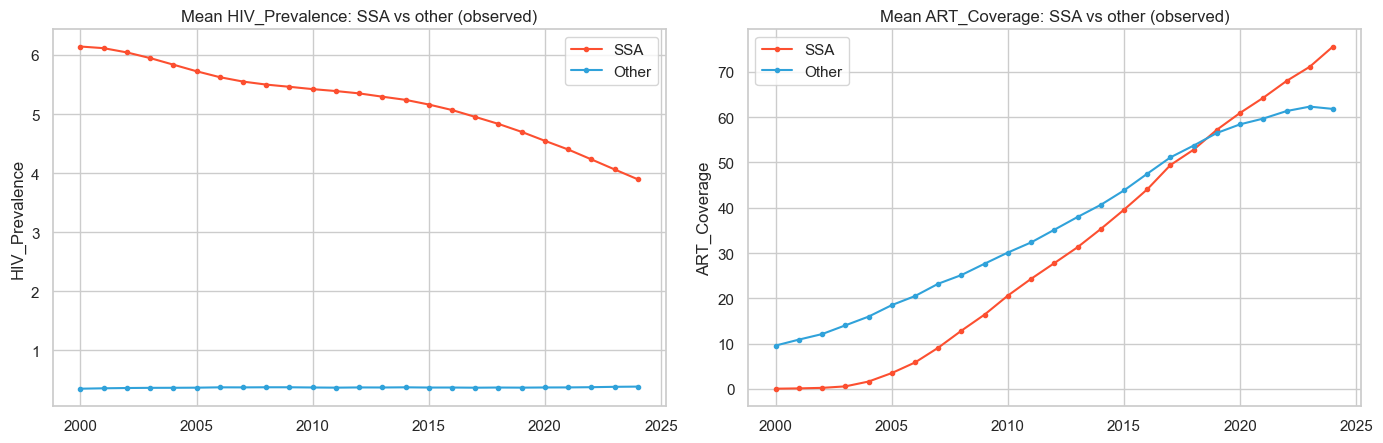

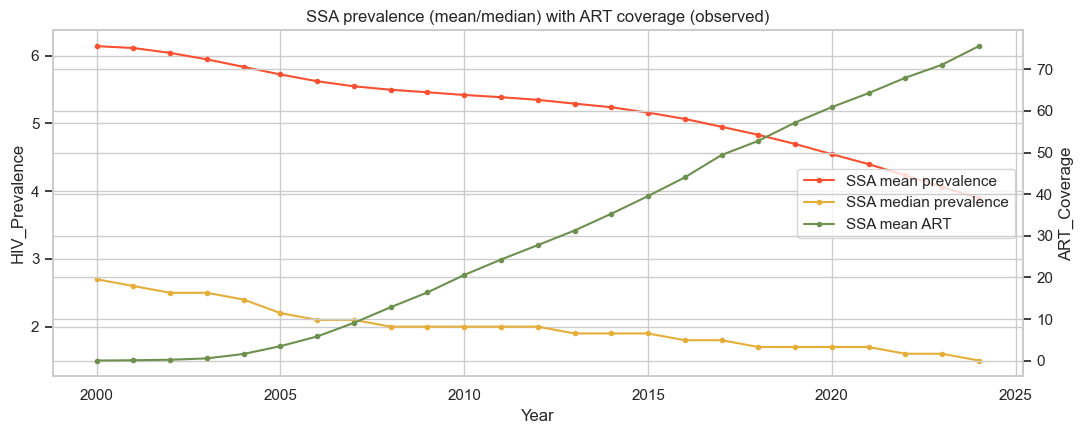

AGENT_SUMMARY ssa_trend_tail_prev:
        mean  median   n
Year                   
2017  4.951     1.8  43
2018  4.833     1.7  43
2019  4.698     1.7  43
2020  4.547     1.7  43
2021  4.400     1.7  43
2022  4.233     1.6  43
2023  4.063     1.6  43
2024  3.895     1.5  43
AGENT_SUMMARY ssa_peak_to_recent_delta:
                 count   mean  median
cluster                              
Other SSA           34 -1.650   -1.35
Southern Africa      9 -6.756   -6.00
AGENT_SUMMARY ssa_largest_declines:
                  Country  peak_year  peak_prev  recent_year  recent_prev  delta
                Zimbabwe       2000       25.8         2024          9.8  -16.0
                Botswana       2000       25.9         2024         15.7  -10.2
                  Malawi       2000       15.3         2024          6.2   -9.1
                 Lesotho       2011       24.9         2024         17.1   -7.8
                Eswatini       2014       29.4         2024         23.4   -6.0
               

In [15]:
# SSA vs other: yearly mean prevalence and ART (observed cells only)
def yearly_region_stat(frame, value_col):
    tmp = frame.dropna(subset=[value_col]).copy()
    tmp["region_bin"] = np.where(
        tmp["World_Bank_Region"].eq(SSA_LABEL).to_numpy(), "SSA", "Other"
    )
    return tmp.groupby(["Year", "region_bin"], as_index=False)[value_col].mean()

prev_y = yearly_region_stat(df, "HIV_Prevalence")
art_y = yearly_region_stat(df, "ART_Coverage")

f, ax = plt.subplots(1, 2, figsize=(14, 4.6))
for region, color in [("SSA", "#fc4f30"), ("Other", "#30a2da")]:
    sub = prev_y[prev_y["region_bin"] == region]
    ax[0].plot(sub["Year"], sub["HIV_Prevalence"], marker=".", color=color, label=region)
ax[0].set_title("Mean HIV_Prevalence: SSA vs other (observed)")
ax[0].set_ylabel("HIV_Prevalence")
ax[0].legend()

for region, color in [("SSA", "#fc4f30"), ("Other", "#30a2da")]:
    sub = art_y[art_y["region_bin"] == region]
    ax[1].plot(sub["Year"], sub["ART_Coverage"], marker=".", color=color, label=region)
ax[1].set_title("Mean ART_Coverage: SSA vs other (observed)")
ax[1].set_ylabel("ART_Coverage")
ax[1].legend()
plt.tight_layout()
plt.show()

# Within SSA: prevalence median + ART mean on twin axis
ssa_prev = (
    df_ssa.dropna(subset=["HIV_Prevalence"])
    .groupby("Year")["HIV_Prevalence"]
    .agg(mean="mean", median="median", n="size")
)
ssa_art = df_ssa.dropna(subset=["ART_Coverage"]).groupby("Year")["ART_Coverage"].mean()

f, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(ssa_prev.index, ssa_prev["mean"], color="#fc4f30", marker=".", label="SSA mean prevalence")
ax1.plot(ssa_prev.index, ssa_prev["median"], color="#e5ae38", marker=".", label="SSA median prevalence")
ax1.set_ylabel("HIV_Prevalence")
ax1.set_xlabel("Year")
ax2 = ax1.twinx()
ax2.plot(ssa_art.index, ssa_art.values, color="#6d904f", marker=".", label="SSA mean ART")
ax2.set_ylabel("ART_Coverage")
ax1.set_title("SSA prevalence (mean/median) with ART coverage (observed)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

# Peak-to-recent change for SSA countries with enough history
hist = (
    df_ssa.dropna(subset=["HIV_Prevalence"])
    .groupby("Country")
    .filter(lambda g: g["Year"].nunique() >= 12)
)
peak = hist.loc[hist.groupby("Country")["HIV_Prevalence"].idxmax()][
    ["Country", "Year", "HIV_Prevalence"]
].rename(columns={"Year": "peak_year", "HIV_Prevalence": "peak_prev"})
recent = (
    hist.sort_values("Year")
    .groupby("Country")
    .tail(1)[["Country", "Year", "HIV_Prevalence"]]
    .rename(columns={"Year": "recent_year", "HIV_Prevalence": "recent_prev"})
)
chg = peak.merge(recent, on="Country")
chg["delta"] = chg["recent_prev"] - chg["peak_prev"]
chg["cluster"] = np.where(
    chg["Country"].isin(SOUTHERN_AFRICA).to_numpy(), "Southern Africa", "Other SSA"
)

print("AGENT_SUMMARY ssa_trend_tail_prev:\n", ssa_prev.tail(8).round(3).to_string())
print("AGENT_SUMMARY ssa_peak_to_recent_delta:")
print(chg.groupby("cluster")["delta"].agg(["count", "mean", "median"]).round(3).to_string())
print(
    "AGENT_SUMMARY ssa_largest_declines:\n",
    chg.nsmallest(8, "delta")[
        ["Country", "peak_year", "peak_prev", "recent_year", "recent_prev", "delta"]
    ].round(2).to_string(index=False),
)


**How to Interpret:** <br>
SSA vs other lines use yearly means of *observed* cells — composition can shift when coverage improves. The twin-axis SSA chart asks whether ART scale-up coincides with prevalence mean/median coming down. Peak-to-recent deltas are descriptive country paths, not causal ART effects (survival on treatment can also keep prevalence from falling as fast as incidence).

**Interpretation:** <br>
SSA stays well above the rest of the world across the surveillance window, even as ART coverage climbs into the high range. Mean above median inside SSA is the Southern Africa tail talking. Many countries sit below their historical peak by the recent year — progress is real and uneven.


### 8.4 Heterogeneity inside SSA — income, ART, and deaths
Still complete-case: income-group prevalence inside SSA, and a recent-year scatter of ART coverage vs AIDS deaths among SSA countries with both measured.


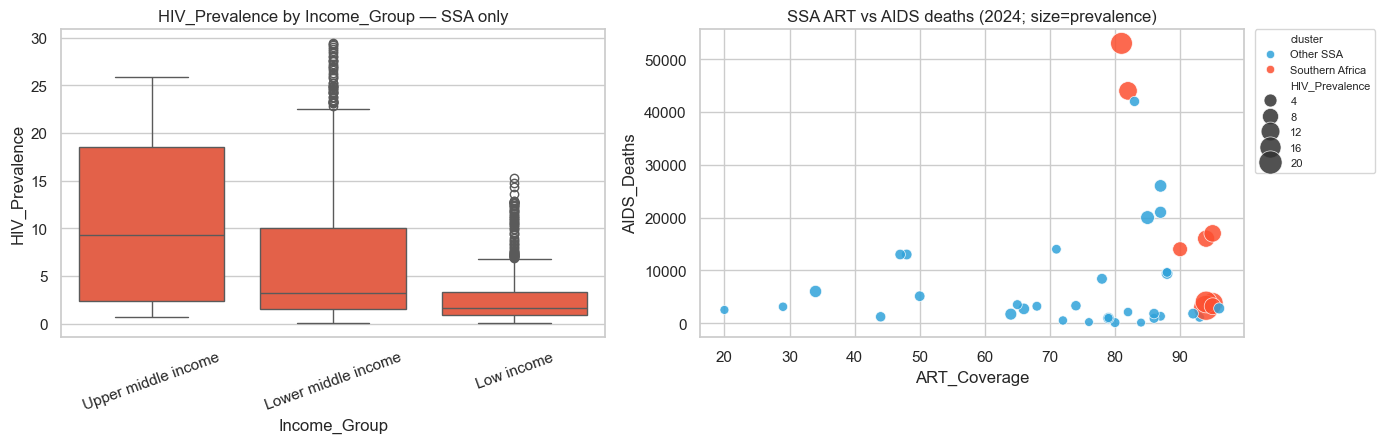

AGENT_SUMMARY ssa_income_prevalence:
                        mean  median  count
Income_Group                              
Upper middle income  10.973    9.30    100
Lower middle income   6.478    3.20    475
Low income            2.872    1.65    500
AGENT_SUMMARY ssa_art_deaths_snapshot_2024:
               Country  HIV_Prevalence  ART_Coverage  AIDS_Deaths        Income_Group         cluster
             Eswatini            23.4          94.0       2900.0 Lower middle income Southern Africa
         South Africa            17.2          81.0      53000.0 Upper middle income Southern Africa
              Lesotho            17.1          94.0       4000.0 Lower middle income Southern Africa
             Botswana            15.7          95.0       3800.0 Upper middle income Southern Africa
           Mozambique            11.5          82.0      44000.0          Low income Southern Africa
             Zimbabwe             9.8          95.0      17000.0 Lower middle income Southern Af

In [16]:
# Income patterning *within* SSA (not the global income story)
ssa_prev_inc = df_ssa.dropna(subset=["HIV_Prevalence", "Income_Group"]).copy()
inc_order = (
    ssa_prev_inc.groupby("Income_Group")["HIV_Prevalence"]
    .median()
    .sort_values(ascending=False)
    .index
)

f, ax = plt.subplots(1, 2, figsize=(14, 4.6))
sns.boxplot(
    data=ssa_prev_inc, x="Income_Group", y="HIV_Prevalence",
    order=inc_order, ax=ax[0], color="#fc4f30",
)
ax[0].tick_params(axis="x", rotation=20)
ax[0].set_title("HIV_Prevalence by Income_Group — SSA only")

ssa_both = df_ssa[(df_ssa["Year"] == y)].dropna(
    subset=["ART_Coverage", "AIDS_Deaths", "HIV_Prevalence"]
).copy()
assert len(ssa_both) >= 15
ssa_both["cluster"] = np.where(
    ssa_both["Country"].isin(SOUTHERN_AFRICA).to_numpy(), "Southern Africa", "Other SSA"
)
sns.scatterplot(
    data=ssa_both, x="ART_Coverage", y="AIDS_Deaths",
    hue="cluster", size="HIV_Prevalence", sizes=(40, 320),
    palette={"Southern Africa": "#fc4f30", "Other SSA": "#30a2da"},
    ax=ax[1], alpha=0.85,
)
ax[1].set_title(f"SSA ART vs AIDS deaths ({y}; size=prevalence)")
ax[1].set_xlabel("ART_Coverage")
ax[1].set_ylabel("AIDS_Deaths")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

watch = ssa_both.sort_values("HIV_Prevalence", ascending=False)[
    ["Country", "HIV_Prevalence", "ART_Coverage", "AIDS_Deaths", "Income_Group", "cluster"]
]
print(
    "AGENT_SUMMARY ssa_income_prevalence:\n",
    ssa_prev_inc.groupby("Income_Group")["HIV_Prevalence"]
    .agg(["mean", "median", "count"]).reindex(inc_order).round(3).to_string(),
)
print(f"AGENT_SUMMARY ssa_art_deaths_snapshot_{y}:\n", watch.head(12).round(2).to_string(index=False))
low_art = watch[watch["ART_Coverage"] < 70].sort_values("HIV_Prevalence", ascending=False)
print("AGENT_SUMMARY ssa_high_prev_art_below_70:\n", low_art.head(8).round(2).to_string(index=False))


**Interpretation:** <br>
Inside SSA, higher income groups do not mean low prevalence — several upper/lower-middle-income Southern African states sit at the top of the epidemic. The ART–deaths scatter separates *coverage* from *absolute death burden*: a large high-ART country can still record many AIDS deaths because the infected population is large. Countries with elevated prevalence and ART still below ~70% are the clearest surveillance flags in this snapshot.

This deep dive sets up the next section: country trajectories for the extreme right tail.


# **9. High-Burden Country Trajectories:** <a id="Countries"></a>


Focus countries: ['Eswatini', 'Lesotho', 'Botswana', 'South Africa', 'Zimbabwe', 'Namibia']


,mean_prev,n,region
Country,,,
Eswatini,27.068,25,Sub-Saharan Africa
Lesotho,22.668,25,Sub-Saharan Africa
Botswana,21.944,25,Sub-Saharan Africa
South Africa,17.164,25,Sub-Saharan Africa
Zimbabwe,16.240,25,Sub-Saharan Africa
Namibia,12.280,25,Sub-Saharan Africa
Zambia,11.700,25,Sub-Saharan Africa
Mozambique,11.684,25,Sub-Saharan Africa


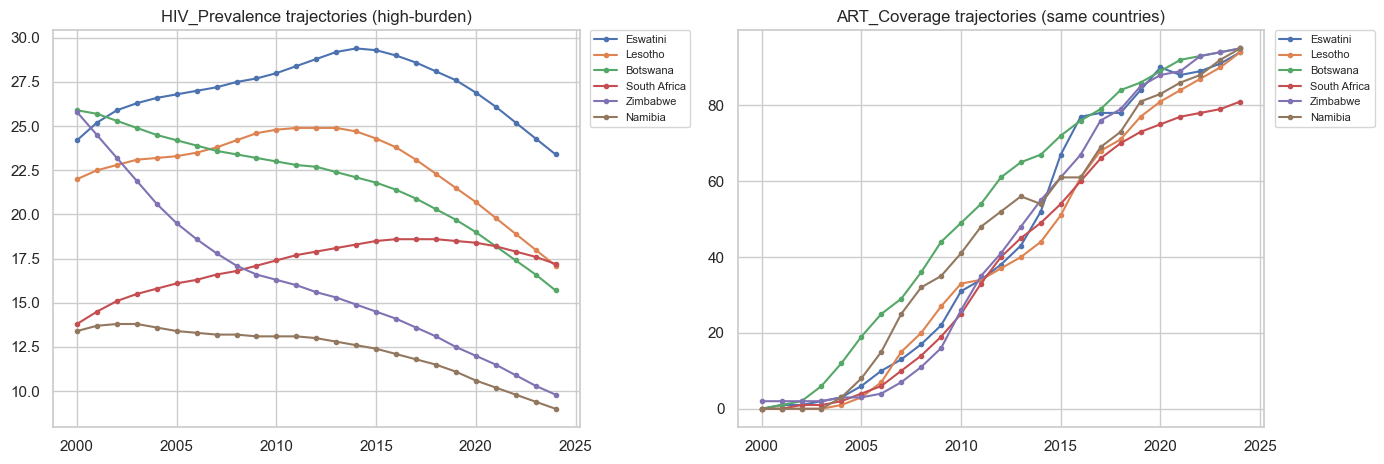

In [17]:
# Pick high-burden countries by mean observed prevalence (min years of data)
country_stats = (
    df.dropna(subset=["HIV_Prevalence"])
    .groupby("Country")
    .agg(mean_prev=("HIV_Prevalence", "mean"), n=("HIV_Prevalence", "size"), region=("World_Bank_Region", "first"))
    .query("n >= 10")
    .sort_values("mean_prev", ascending=False)
)
focus_countries = country_stats.head(6).index.tolist()
assert len(focus_countries) >= 4
print("Focus countries:", focus_countries)
display(country_stats.head(8))

traj = df[df["Country"].isin(focus_countries)].copy()

f, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for c in focus_countries:
    sub = traj[traj["Country"] == c].sort_values("Year")
    ax[0].plot(sub["Year"], sub["HIV_Prevalence"], marker=".", label=c)
ax[0].set_title("HIV_Prevalence trajectories (high-burden)")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)

for c in focus_countries:
    sub = traj[traj["Country"] == c].sort_values("Year")
    ax[1].plot(sub["Year"], sub["ART_Coverage"], marker=".", label=c)
ax[1].set_title("ART_Coverage trajectories (same countries)")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()


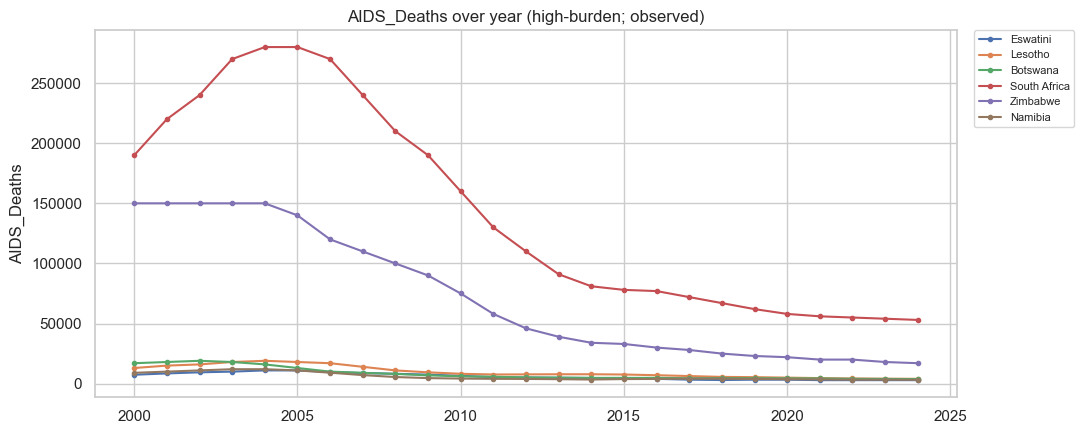

AGENT_SUMMARY within_country_art_deaths:
      Country  n  spearman_art_deaths  art_start  art_end  deaths_start  deaths_end
    Eswatini 25               -0.926        0.0     94.0        7400.0      2900.0
     Lesotho 25               -0.958        0.0     94.0       13000.0      4000.0
    Botswana 25               -0.992        0.0     95.0       17000.0      3800.0
South Africa 25               -0.942        0.0     81.0      190000.0     53000.0
    Zimbabwe 25               -0.997        2.0     95.0      150000.0     17000.0
     Namibia 25               -0.905        0.0     95.0        9000.0      3200.0


In [18]:
# Deaths vs ART for focus countries where both exist
f, ax = plt.subplots(figsize=(11, 4.5))
for c in focus_countries:
    sub = traj[traj["Country"] == c].dropna(subset=["ART_Coverage", "AIDS_Deaths"]).sort_values("Year")
    if len(sub) >= 5:
        ax.plot(sub["Year"], sub["AIDS_Deaths"], marker=".", label=c)
ax.set_title("AIDS_Deaths over year (high-burden; observed)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)
ax.set_ylabel("AIDS_Deaths")
plt.tight_layout()
plt.show()

# Simple within-country association: ART up, deaths down?
rows = []
for c in focus_countries:
    sub = traj[traj["Country"] == c].dropna(subset=["ART_Coverage", "AIDS_Deaths"])
    if len(sub) >= 6:
        rows.append({
            "Country": c,
            "n": len(sub),
            "spearman_art_deaths": stats.spearmanr(sub["ART_Coverage"], sub["AIDS_Deaths"]).correlation,
            "art_start": sub.sort_values("Year")["ART_Coverage"].iloc[0],
            "art_end": sub.sort_values("Year")["ART_Coverage"].iloc[-1],
            "deaths_start": sub.sort_values("Year")["AIDS_Deaths"].iloc[0],
            "deaths_end": sub.sort_values("Year")["AIDS_Deaths"].iloc[-1],
        })
art_death_summary = pd.DataFrame(rows)
print("AGENT_SUMMARY within_country_art_deaths:\n", art_death_summary.round(3).to_string(index=False))


**Interpretation:** <br>
High-burden trajectories often show prevalence stabilizing or declining as ART coverage climbs, with deaths falling in the treatment era — the epidemic transition narrative in miniature. Within-country Spearman signs that are negative (ART up, deaths down) support that story without proving counterfactuals. Gaps in a country's line are missing surveillance years, not zeros.


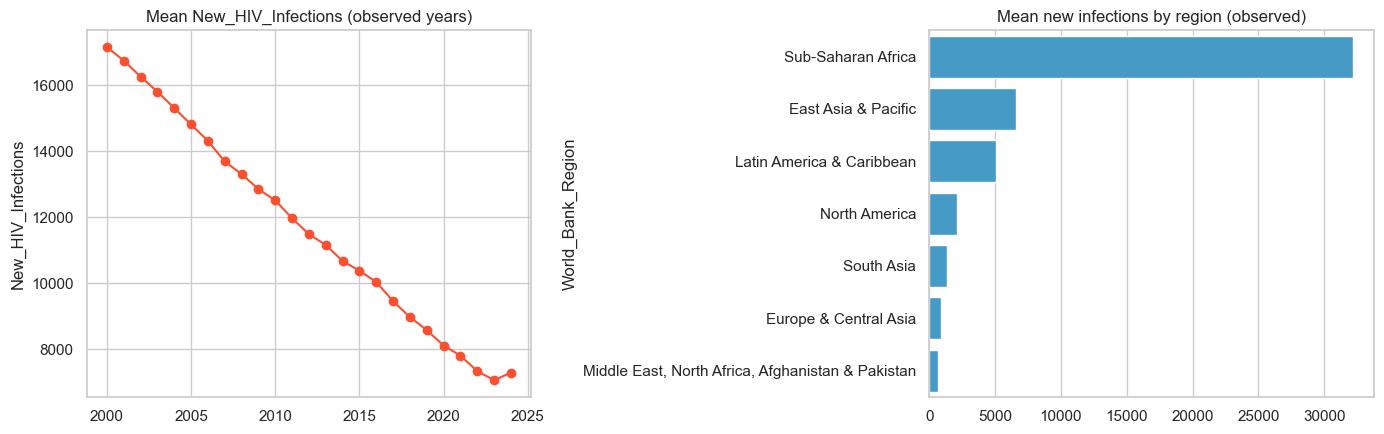

AGENT_SUMMARY new_infections_yearly_tail:
  Year  mean_new  mean_prev   n
 2017   9452.39       1.76 142
 2018   8970.07       1.73 142
 2019   8577.61       1.68 142
 2020   8108.73       1.64 142
 2021   7803.24       1.60 142
 2022   7332.82       1.55 142
 2023   7060.86       1.53 139
 2024   7287.93       1.51 135
AGENT_SUMMARY new_infections_by_region:
 World_Bank_Region
Sub-Saharan Africa                                   32177.88
East Asia & Pacific                                   6595.84
Latin America & Caribbean                             5033.20
North America                                         2121.74
South Asia                                            1353.17
Europe & Central Asia                                  866.46
Middle East, North Africa, Afghanistan & Pakistan      663.69


In [19]:
# New infections where available — another complete-case lens
inf = df.dropna(subset=["New_HIV_Infections", "HIV_Prevalence"]).copy()
inf_year = inf.groupby("Year").agg(
    mean_new=("New_HIV_Infections", "mean"),
    mean_prev=("HIV_Prevalence", "mean"),
    n=("New_HIV_Infections", "size"),
).reset_index()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(inf_year["Year"], inf_year["mean_new"], color="#fc4f30", marker="o")
ax[0].set_title("Mean New_HIV_Infections (observed years)")
ax[0].set_ylabel("New_HIV_Infections")

reg_new = inf.groupby("World_Bank_Region")["New_HIV_Infections"].mean().sort_values(ascending=False)
sns.barplot(x=reg_new.values, y=reg_new.index, ax=ax[1], color="#30a2da")
ax[1].set_title("Mean new infections by region (observed)")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY new_infections_yearly_tail:\n", inf_year.tail(8).round(2).to_string(index=False))
print("AGENT_SUMMARY new_infections_by_region:\n", reg_new.round(2).to_string())


**Code Explanation:** <br>
New infections are another incomplete series. I only average observed cells and print the yearly n so a coverage jump is not mistaken for an epidemiological miracle.


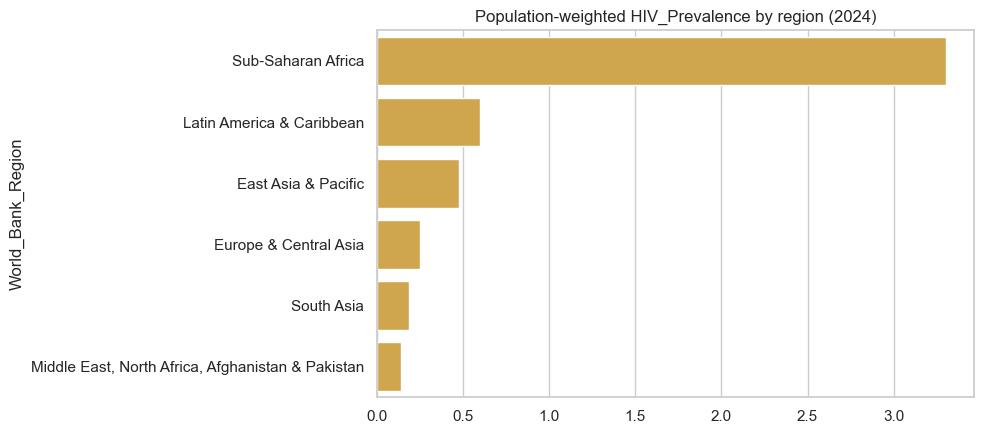

AGENT_SUMMARY pop_weighted_prevalence_year=2024
World_Bank_Region
Sub-Saharan Africa                                   3.3021
Latin America & Caribbean                            0.5944
East Asia & Pacific                                  0.4751
Europe & Central Asia                                0.2489
South Asia                                           0.1865
Middle East, North Africa, Afghanistan & Pakistan    0.1371


In [20]:
# Population-weighted regional prevalence for a recent year with decent coverage
years_with_cov = (
    df.groupby("Year")["HIV_Prevalence"]
    .apply(lambda s: s.notna().mean())
)
y = int(years_with_cov[years_with_cov >= 0.5].index.max())
snap = df[(df["Year"] == y) & df["HIV_Prevalence"].notna() & df["Population"].notna()].copy()
assert len(snap) > 50
snap["prev_pop"] = snap["HIV_Prevalence"] * snap["Population"]
weighted = snap.groupby("World_Bank_Region").apply(
    lambda g: g["prev_pop"].sum() / g["Population"].sum(), include_groups=False
).sort_values(ascending=False)

f, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=weighted.values, y=weighted.index, ax=ax, color="#e5ae38")
ax.set_title(f"Population-weighted HIV_Prevalence by region ({y})")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY pop_weighted_prevalence_year={}".format(y))
print(weighted.round(4).to_string())


**Interpretation:** <br>
Unweighted country means treat Luxembourg and Nigeria alike. Population-weighted regional prevalence re-centers the map on where people live. If Sub-Saharan Africa still dominates after weighting, the burden story is not an artifact of many small high-prevalence states alone.


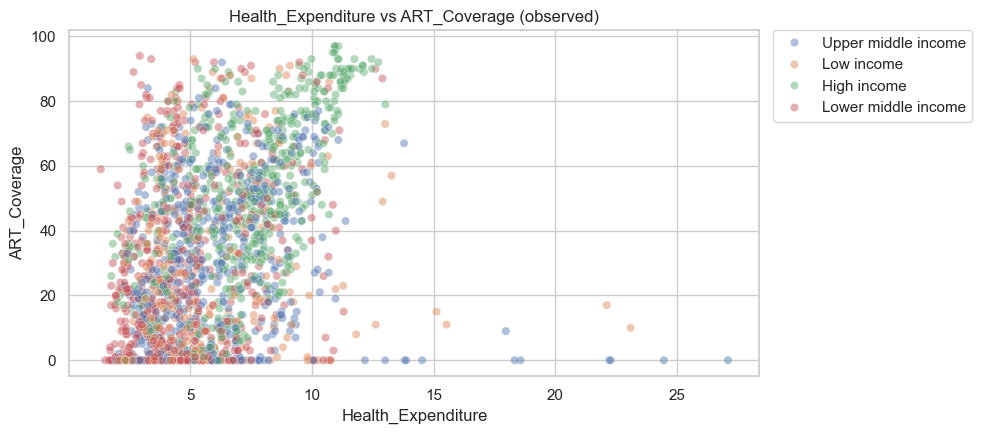

AGENT_SUMMARY spearman health_exp~ART=0.378 n=3352


In [21]:
# Health expenditure vs ART coverage (associational complete cases)
hx = df.dropna(subset=["Health_Expenditure", "ART_Coverage"]).copy()
f, ax = plt.subplots(figsize=(10, 4.5))
sample = hx.sample(min(2000, len(hx)), random_state=2)
sns.scatterplot(data=sample, x="Health_Expenditure", y="ART_Coverage", hue="Income_Group", alpha=0.45, ax=ax)
ax.set_title("Health_Expenditure vs ART_Coverage (observed)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY spearman health_exp~ART={:.3f} n={}".format(
    stats.spearmanr(hx["Health_Expenditure"], hx["ART_Coverage"]).correlation, len(hx)
))


**How to Interpret:** <br>
Health spending and ART coverage co-move imperfectly. Aid-financed treatment can raise ART without raising domestic health expenditure in the same way; income-group hue keeps that institutional mix visible.


# **10. What It Means — Working Synthesis:** <a id="Synthesis"></a>


In [22]:
# Compact numeric synthesis for agent-readable closeout
ssa = df["World_Bank_Region"].eq("Sub-Saharan Africa")
obs_prev = df["HIV_Prevalence"].notna()
summary = {
    "rows": len(df),
    "countries": df["Country"].nunique(),
    "prevalence_nonnull_share": float(obs_prev.mean()),
    "art_nonnull_share": float(df["ART_Coverage"].notna().mean()),
    "deaths_nonnull_share": float(df["AIDS_Deaths"].notna().mean()),
    "ssa_share_of_obs_prevalence_mass": float(
        df.loc[obs_prev & ssa, "HIV_Prevalence"].sum() / df.loc[obs_prev, "HIV_Prevalence"].sum()
    ),
    "mean_art_2005": float(df.loc[df["Year"].eq(2005), "ART_Coverage"].mean(skipna=True)),
    "mean_art_2020": float(df.loc[df["Year"].eq(2020), "ART_Coverage"].mean(skipna=True)),
}
print("AGENT_SUMMARY synthesis:")
for k, v in summary.items():
    print(f"  {k}: {v}")


AGENT_SUMMARY synthesis:
  rows: 7500
  countries: 216
  prevalence_nonnull_share: 0.4924
  art_nonnull_share: 0.48333333333333334
  deaths_nonnull_share: 0.4686666666666667
  ssa_share_of_obs_prevalence_mass: 0.8522383751841895
  mean_art_2005: 14.090909090909092
  mean_art_2020: 59.15068493150685


**Numeric closeout above; narrative synthesis below.**

# **What It Means — Working Synthesis**

**What the table is:** <br>
A country–year HIV/AIDS panel (1990–2024) with region, income, prevalence, ART, deaths, and development covariates. Sibling files exist; this notebook stays on `clean_aids_dataset.csv`. Missingness is structural and era-dependent — not a cosmetic inconvenience.

**What stands out:** <br>
1. **Coverage opens late.** Prevalence/ART/deaths are sparse in the early 1990s and denser later; trends are among observed cells.
2. **Sub-Saharan Africa dominates high prevalence** — by prevalence mass, population-weighted rates, and PLHIV share, not just unweighted means.
3. **Within SSA the epidemic is uneven:** a Southern Africa cluster forms the extreme right tail; West/Central/East Africa sit lower but are not negligible.
4. **ART rises as deaths fall in complete-case views** — the treatment-era transition, associationally; SSA mean prevalence stays far above the rest of the world.
5. **Income and GDP pattern with prevalence**, but regional clustering (and high-prevalence middle-income Southern African states) forbid casual causal talk.
6. **High-burden country paths** often show ART scale-up alongside declining deaths where both series are measured.
7. **No silent imputation** was used for key outcomes; complete-case subsets are declared when required.

**Open follow-ups:** <br>
- How sensitive are regional means to reweighting by population or by people living with HIV?
- Can ART–death lags (coverage this year vs deaths next year) sharpen the transition story?
- Which countries gained surveillance coverage earliest, and does that bias early global means?
- How stable is the Southern Africa vs other SSA gap under population weighting or PLHIV weighting?
- How do tuberculosis coinfection patterns track the ART era in the subset where that metric exists?
